<a href="https://colab.research.google.com/github/lgplorea/EjerciciosPython/blob/main/Copia_de_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Librerías importadas correctamente
✅ Las fotos ya estaban descomprimidas.
   🐱 Fotos de gatos encontradas: 85
   🐶 Fotos de perros encontradas: 108

📊 Dataset original: 193 animales en total
   Distribución por resultado:
Outcome Type
Adoption           135
Transfer            38
Return to Owner     17
Euthanasia           2
Died                 1

✅ Nos quedamos con 135 animales adoptados

🏷️  Distribución de clases:
   Clase 0 (< 63 días, rápido): 69 animales
   Clase 1 (≥ 63 días, lento): 66 animales
   → Las clases están bien equilibradas ✅

🖼️  Cargando imágenes (128×128 px)...
✅ Imágenes cargadas: 135
   Forma del array de imágenes: (135, 128, 128, 3)
   → Interpretación: 135 imágenes, de 128×128 px, con 3 canales de color (RGB)

📂 División de datos:
   Entrenamiento: 108 imágenes  (clase 0: 55, clase 1: 53)
   Validación:    27 imágenes  (clase 0: 14, clase 1: 13)


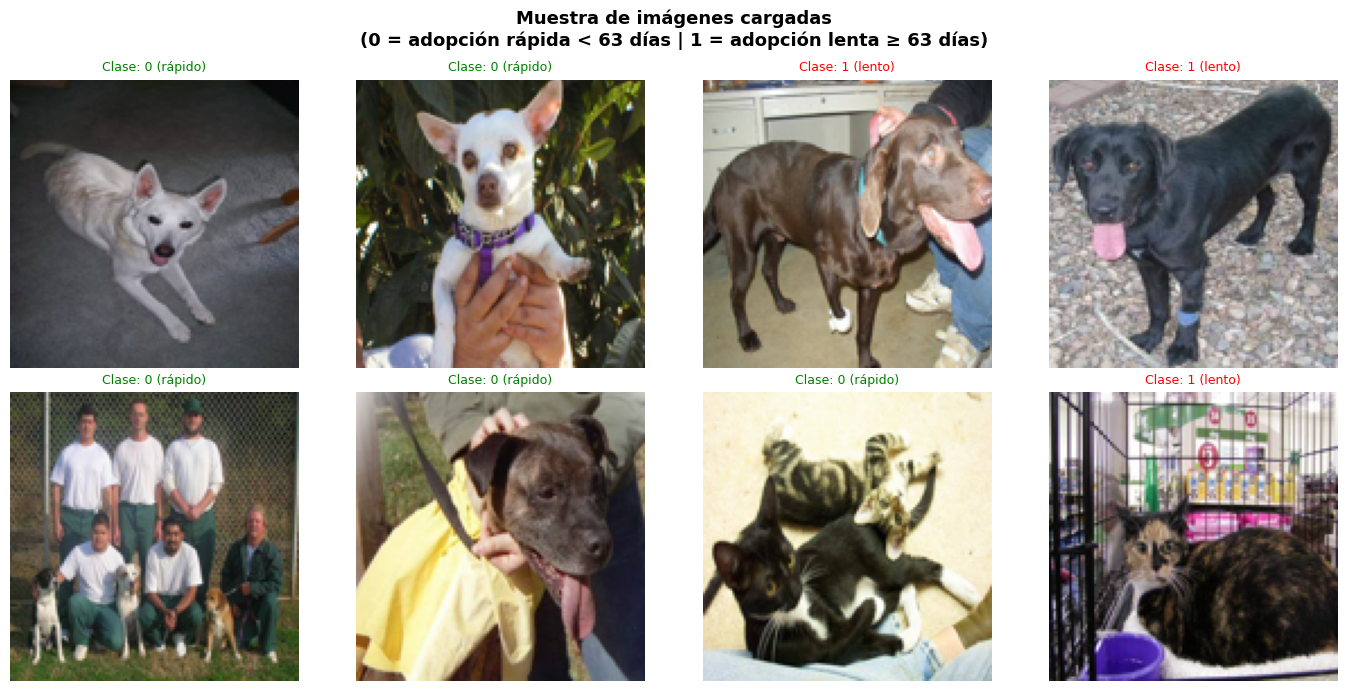


✅ BLOQUE 1 COMPLETADO. Puedes ejecutar el Bloque 2.
   Variables disponibles para el siguiente bloque: X_train, X_val, y_train, y_val


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOQUE 1 DE 5 · Preparación de datos                                       ║
# ║  Red Neuronal para predecir velocidad de adopción de animales                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
# QUÉ HACE ESTE BLOQUE:
#   1. Instala las librerías necesarias
#   2. Descomprime el ZIP con las fotos
#   3. Lee el CSV y filtra solo los animales ADOPTADOS
#   4. Crea la etiqueta: 0 = adoptado en < 63 días | 1 = adoptado en ≥ 63 días
#   5. Carga todas las imágenes y las prepara para la red neuronal
#   6. Divide los datos en entrenamiento (80%) y validación (20%)
#
# ANTES DE EJECUTAR: sube 'bbdd_con_fotos.csv' y 'fotos_asignadas.zip' a Colab
# usando el panel de archivos (icono de carpeta en la barra izquierda).

# ── Paso 1: Instalar librerías ────────────────────────────────────────────────
# TensorFlow: la librería principal para crear redes neuronales
# scikit-learn: para dividir los datos en entrenamiento y validación
# matplotlib: para dibujar gráficos
# Estas librerías ya suelen estar en Colab, pero la instalación asegura
# que tengamos las versiones correctas.

!pip install tensorflow scikit-learn matplotlib pillow --quiet

# ── Paso 2: Importar todo lo que vamos a usar ─────────────────────────────────
# 'import' es como abrir una caja de herramientas específica

import os            # Para trabajar con rutas de archivos y carpetas
import zipfile       # Para descomprimir el ZIP
import numpy as np   # Para trabajar con matrices de números (las imágenes)
import pandas as pd  # Para leer el CSV como una tabla
import matplotlib.pyplot as plt  # Para dibujar gráficos

from PIL import Image    # Para abrir y redimensionar imágenes
from sklearn.model_selection import train_test_split  # Para dividir datos

print("✅ Librerías importadas correctamente")

# ── Paso 3: Descomprimir el ZIP con las fotos ─────────────────────────────────
# El ZIP contiene una carpeta 'fotos_asignadas/' con subcarpetas 'cats/' y 'dogs/'

ZIP_PATH = 'fotos_asignadas.zip'   # Nombre del ZIP que subiste a Colab
FOTOS_DIR = '.'                    # Descomprimimos en el directorio actual

if not os.path.exists('fotos_asignadas'):
    print("📦 Descomprimiendo el ZIP de fotos...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(FOTOS_DIR)
    print("✅ ZIP descomprimido. Carpeta 'fotos_asignadas/' creada.")
else:
    print("✅ Las fotos ya estaban descomprimidas.")

# Verificamos que las fotos están ahí
n_cats = len([f for f in os.listdir('fotos_asignadas/cats') if f.endswith('.jpg')])
n_dogs = len([f for f in os.listdir('fotos_asignadas/dogs') if f.endswith('.jpg')])
print(f"   🐱 Fotos de gatos encontradas: {n_cats}")
print(f"   🐶 Fotos de perros encontradas: {n_dogs}")

# ── Paso 4: Leer el CSV y crear etiquetas ────────────────────────────────────
# El CSV tiene una fila por animal con sus datos, incluyendo:
#   - 'Outcome Type': si fue adoptado, transferido, etc.
#   - 'dias_estancia': cuántos días estuvo en el refugio
#   - 'foto_asignada_simulada': ruta relativa a su foto (ej: dogs/dog.123.jpg)

CSV_PATH = 'bbdd_con_fotos.csv'
df = pd.read_csv(CSV_PATH)

print(f"\n📊 Dataset original: {len(df)} animales en total")
print(f"   Distribución por resultado:")
print(df['Outcome Type'].value_counts().to_string())

# Filtramos SOLO los adoptados (descartamos Transfers, Euthanasias, etc.)
df_adoptados = df[df['Outcome Type'] == 'Adoption'].copy()
print(f"\n✅ Nos quedamos con {len(df_adoptados)} animales adoptados")

# Creamos la etiqueta binaria (0 o 1)
# np.where(condición, valor_si_verdad, valor_si_falso)
UMBRAL_DIAS = 63  # El corte que separa adopción "rápida" de "lenta"

df_adoptados['etiqueta'] = np.where(
    df_adoptados['dias_estancia'] < UMBRAL_DIAS,
    0,   # Clase 0: adoptado en menos de 63 días (rápido)
    1    # Clase 1: adoptado en 63 días o más (lento)
)

print(f"\n🏷️  Distribución de clases:")
print(f"   Clase 0 (< {UMBRAL_DIAS} días, rápido): {(df_adoptados['etiqueta'] == 0).sum()} animales")
print(f"   Clase 1 (≥ {UMBRAL_DIAS} días, lento): {(df_adoptados['etiqueta'] == 1).sum()} animales")
print(f"   → Las clases están {'bien equilibradas ✅' if abs((df_adoptados['etiqueta']==0).sum() - (df_adoptados['etiqueta']==1).sum()) < 15 else 'algo desequilibradas ⚠️'}")

# ── Paso 5: Cargar y preparar las imágenes ───────────────────────────────────
# Las redes neuronales necesitan que todas las imágenes tengan el mismo tamaño.
# Usamos 128x128 píxeles: suficiente para capturar detalles, manejable en memoria.
# Los valores de color van de 0 a 255; los dividimos por 255 para obtener 0-1.
# Esto se llama normalización y ayuda mucho al aprendizaje.

TAMANO_IMAGEN = (128, 128)  # Ancho x Alto en píxeles

imagenes = []   # Lista donde guardaremos los arrays numéricos de las imágenes
etiquetas = []  # Lista paralela con la clase de cada imagen (0 o 1)
errores = []    # Si alguna foto no se encuentra, la anotamos

print(f"\n🖼️  Cargando imágenes ({TAMANO_IMAGEN[0]}×{TAMANO_IMAGEN[1]} px)...")

for idx, fila in df_adoptados.iterrows():
    # Construimos la ruta completa a la foto
    ruta_foto = os.path.join('fotos_asignadas', fila['foto_asignada_simulada'])

    if os.path.exists(ruta_foto):
        # Abrimos la imagen y la redimensionamos
        img = Image.open(ruta_foto).convert('RGB')   # 'RGB' = 3 canales de color
        img = img.resize(TAMANO_IMAGEN)               # Redimensionar
        arr = np.array(img) / 255.0                  # Convertir a array y normalizar

        imagenes.append(arr)
        etiquetas.append(fila['etiqueta'])
    else:
        errores.append(ruta_foto)

if errores:
    print(f"⚠️  No se encontraron {len(errores)} fotos")

# Convertimos las listas a arrays de NumPy (el formato que necesita TensorFlow)
X = np.array(imagenes)   # Shape: (num_animales, 128, 128, 3)
y = np.array(etiquetas)  # Shape: (num_animales,)

print(f"✅ Imágenes cargadas: {X.shape[0]}")
print(f"   Forma del array de imágenes: {X.shape}")
print(f"   → Interpretación: {X.shape[0]} imágenes, de {X.shape[1]}×{X.shape[2]} px, con {X.shape[3]} canales de color (RGB)")

# ── Paso 6: Dividir en entrenamiento y validación ────────────────────────────
# train_test_split divide aleatoriamente los datos.
# test_size=0.2 → 20% para validación, 80% para entrenamiento.
# random_state=42 → número semilla para que la división sea siempre igual
#   (si vuelves a ejecutar el código, obtienes la misma división).
# stratify=y → asegura que ambos conjuntos tengan proporción similar de 0s y 1s.

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # Mantiene la proporción de clases en ambos conjuntos
)

print(f"\n📂 División de datos:")
print(f"   Entrenamiento: {len(X_train)} imágenes  (clase 0: {(y_train==0).sum()}, clase 1: {(y_train==1).sum()})")
print(f"   Validación:    {len(X_val)} imágenes  (clase 0: {(y_val==0).sum()}, clase 1: {(y_val==1).sum()})")

# ── Visualización de muestra ─────────────────────────────────────────────────
# Mostramos 8 imágenes de ejemplo para verificar que todo se cargó bien

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Muestra de imágenes cargadas\n(0 = adopción rápida < 63 días | 1 = adopción lenta ≥ 63 días)',
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < len(X_train):
        ax.imshow(X_train[i])
        ax.set_title(f'Clase: {int(y_train[i])} ({"rápido" if y_train[i]==0 else "lento"})',
                     fontsize=9,
                     color='green' if y_train[i] == 0 else 'red')
        ax.axis('off')

plt.tight_layout()
plt.show()

print("\n✅ BLOQUE 1 COMPLETADO. Puedes ejecutar el Bloque 2.")
print(f"   Variables disponibles para el siguiente bloque: X_train, X_val, y_train, y_val")

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOQUE 2 DE 5 · Construcción del modelo                                    ║
# ║  Red Neuronal para predecir velocidad de adopción de animales                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
# QUÉ HACE ESTE BLOQUE:
#   1. Carga MobileNetV2, una red preentrenada por Google con millones de imágenes
#   2. Añade nuestras propias capas finales adaptadas a nuestro problema
#   3. Compila el modelo (le dice cómo aprender y qué medir)
#   4. Muestra un resumen de la arquitectura
#
# IMPORTANTE: ejecuta el Bloque 1 antes que este.
# Las variables X_train, X_val, y_train, y_val deben existir en memoria.

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

print(f"TensorFlow versión: {tf.__version__}")

# ── Paso 1: Cargar MobileNetV2 (la base preentrenada) ────────────────────────
# MobileNetV2 fue entrenada por Google con ImageNet: 1.2 millones de imágenes,
# 1000 categorías diferentes. Ya "sabe" detectar bordes, texturas, formas...
#
# include_top=False → no incluimos las capas finales originales (que clasifican
#   en 1000 categorías), porque nosotros solo necesitamos 2.
# weights='imagenet' → usamos los pesos ya entrenados (el "conocimiento" previo).
# input_shape → le decimos el tamaño de nuestras imágenes (128x128, 3 canales RGB).

print("📥 Descargando MobileNetV2 preentrenado...")
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

# Congelamos los pesos de la base: no queremos que el entrenamiento cambie
# lo que MobileNetV2 ya aprendió. Solo entrenaremos nuestras capas finales.
# Esto es esencial con pocos datos: si entrenáramos toda la red, olvidaría
# lo que aprendió con millones de imágenes y sobreajustaría con las nuestras.
base_model.trainable = False

print(f"✅ MobileNetV2 cargado y congelado")
print(f"   Número de capas en la base: {len(base_model.layers)}")
print(f"   Parámetros de la base (congelados): {base_model.count_params():,}")

# ── Paso 2: Añadir nuestras capas finales ────────────────────────────────────
# Construimos el modelo completo añadiendo capas sobre la base.
# Usamos la API funcional de Keras: definimos el flujo de datos explícitamente.

# Entrada: las imágenes de 128x128 píxeles con 3 canales de color
inputs = tf.keras.Input(shape=(128, 128, 3), name='entrada_imagen')

# Preprocesamiento específico de MobileNetV2: convierte los píxeles de 0-1
# al rango que espera el modelo (-1 a 1)
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)

# La base preentrenada extrae características visuales (bordes, texturas, formas)
x = base_model(x, training=False)
# training=False → la base siempre se comporta como en "modo evaluación",
# importante para las capas de normalización internas

# GlobalAveragePooling2D: toma el mapa de características espacial y lo convierte
# en un único vector por canal. Es una forma de "resumir" toda la información
# espacial en un vector compacto. Alternativa más simple que Flatten().
x = layers.GlobalAveragePooling2D(name='pooling_global')(x)

# Dropout: durante el entrenamiento, "apaga" aleatoriamente el 20% de las neuronas
# en cada paso. Esto obliga a la red a no depender de neuronas concretas y
# aprende representaciones más robustas → reduce overfitting.
# Durante la validación/predicción, el dropout se desactiva automáticamente.
x = layers.Dropout(0.20, name='dropout_regularizacion')(x)

# Capa densa final: 1 neurona con función de activación sigmoid.
# Sigmoid convierte cualquier número en un valor entre 0 y 1.
# Lo interpretamos como: probabilidad de que el animal sea "clase 1" (lento).
# Si el resultado es < 0.5 → predice clase 0 (rápido)
# Si el resultado es ≥ 0.5 → predice clase 1 (lento)
salida = layers.Dense(1, activation='sigmoid', name='prediccion')(x)

# Creamos el modelo conectando entrada y salida
modelo = Model(inputs=inputs, outputs=salida, name='red_adopcion_animales')

print("\n🏗️  Arquitectura del modelo construida")

# ── Paso 3: Compilar el modelo ───────────────────────────────────────────────
# Compilar = decirle al modelo CÓMO va a aprender:
#
# optimizer='adam':
#   Adam es el optimizador más popular en deep learning. Ajusta automáticamente
#   la velocidad de aprendizaje (learning rate) para cada parámetro.
#   Es robusto y funciona bien sin necesidad de ajuste manual.
#
# loss='binary_crossentropy':
#   Es la función de pérdida estándar para clasificación binaria (2 clases).
#   Mide cuánto se equivoca el modelo: si predice 0.9 cuando la respuesta
#   correcta es 0, la pérdida es alta; si predice 0.05 cuando es 0, es baja.
#   El entrenamiento busca minimizar este número.
#
# metrics=['accuracy']:
#   Accuracy = porcentaje de predicciones correctas.
#   Es lo que vemos durante el entrenamiento para saber si mejora.

modelo.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ── Paso 4: Resumen del modelo ───────────────────────────────────────────────
# model.summary() muestra todas las capas, su forma de salida y el número
# de parámetros (parámetros = los números internos que el modelo ajusta al aprender)

print("\n📋 RESUMEN DEL MODELO:")
modelo.summary()

# Contamos parámetros entrenables vs congelados
params_totales = modelo.count_params()
params_entrenables = sum([tf.size(w).numpy() for w in modelo.trainable_weights])
params_congelados = params_totales - params_entrenables

print(f"\n📊 Parámetros:")
print(f"   Totales: {params_totales:,}")
print(f"   Entrenables (los nuestros): {params_entrenables:,}")
print(f"   Congelados (MobileNetV2): {params_congelados:,}")
print(f"   → Solo entrenamos el {100*params_entrenables/params_totales:.1f}% de los parámetros")

# ── Diagrama visual de la arquitectura ───────────────────────────────────────
# Mostramos un esquema simplificado para entender el flujo de datos

print("\n🔷 FLUJO DEL MODELO (simplificado):")
print("   ┌─────────────────────────────────────────────────────┐")
print("   │  ENTRADA: imagen 128×128×3 (color RGB)              │")
print("   └──────────────────────┬──────────────────────────────┘")
print("                          ▼")
print("   ┌─────────────────────────────────────────────────────┐")
print("   │  MobileNetV2 CONGELADO                              │")
print("   │  Extrae características: bordes, texturas, formas   │")
print("   │  (ya entrenado con millones de imágenes de Google)  │")
print("   └──────────────────────┬──────────────────────────────┘")
print("                          ▼")
print("   ┌─────────────────────────────────────────────────────┐")
print("   │  GlobalAveragePooling2D                             │")
print("   │  Resume las características en un vector            │")
print("   └──────────────────────┬──────────────────────────────┘")
print("                          ▼")
print("   ┌─────────────────────────────────────────────────────┐")
print("   │  Dropout (20%)                                      │")
print("   │  Apaga neuronas aleatoriamente → evita overfitting  │")
print("   └──────────────────────┬──────────────────────────────┘")
print("                          ▼")
print("   ┌─────────────────────────────────────────────────────┐")
print("   │  Dense(1, sigmoid)  ← nuestras capas entrenables   │")
print("   │  Salida: número entre 0 y 1                         │")
print("   │  < 0.5  →  Clase 0 (adopción rápida, < 63 días)    │")
print("   │  ≥ 0.5  →  Clase 1 (adopción lenta, ≥ 63 días)     │")
print("   └─────────────────────────────────────────────────────┘")

print("\n✅ BLOQUE 2 COMPLETADO. Puedes ejecutar el Bloque 3.")
print("   Variable disponible para el siguiente bloque: modelo")


TensorFlow versión: 2.20.0
📥 Descargando MobileNetV2 preentrenado...
✅ MobileNetV2 cargado y congelado
   Número de capas en la base: 154
   Parámetros de la base (congelados): 2,257,984

🏗️  Arquitectura del modelo construida

📋 RESUMEN DEL MODELO:


Model: "red_adopcion_animales"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada_imagen (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply_1 (Multiply)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_global                  │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_regularizacion          │ (None, 1280)           │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediccion (Dense)              │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


📊 Parámetros:
   Totales: 2,259,265
   Entrenables (los nuestros): 1,281
   Congelados (MobileNetV2): 2,257,984
   → Solo entrenamos el 0.1% de los parámetros

🔷 FLUJO DEL MODELO (simplificado):
   ┌─────────────────────────────────────────────────────┐
   │  ENTRADA: imagen 128×128×3 (color RGB)              │
   └──────────────────────┬──────────────────────────────┘
                          ▼
   ┌─────────────────────────────────────────────────────┐
   │  MobileNetV2 CONGELADO                              │
   │  Extrae características: bordes, texturas, formas   │
   │  (ya entrenado con millones de imágenes de Google)  │
   └──────────────────────┬──────────────────────────────┘
                          ▼
   ┌─────────────────────────────────────────────────────┐
   │  GlobalAveragePooling2D                             │
   │  Resume las características en un vector            │
   └──────────────────────┬──────────────────────────────┘
                          ▼
   ┌────────

🚀 Configurando el entrenamiento...
✅ Callbacks configurados:
   - EarlyStopping: para si no mejora en 5 épocas
   - ReduceLROnPlateau: reduce la velocidad de aprendizaje si se estanca

🔁 Iniciando entrenamiento...
   Imágenes de entrenamiento: 108
   Imágenes de validación: 27
   Épocas máximas: 20
   Tamaño de lote (batch): 16

────────────────────────────────────────────────────────────
Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.4907 - loss: 0.8427 - val_accuracy: 0.5556 - val_loss: 0.7547 - learning_rate: 0.0010
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5648 - loss: 0.7129 - val_accuracy: 0.5556 - val_loss: 0.7806 - learning_rate: 0.0010
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7037 - loss: 0.6025 - val_accuracy: 0.5185 - val_loss: 0.8111 - learning_rate: 0.0010
Epoch 4/20
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7342 - loss: 0.5223
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
7/7

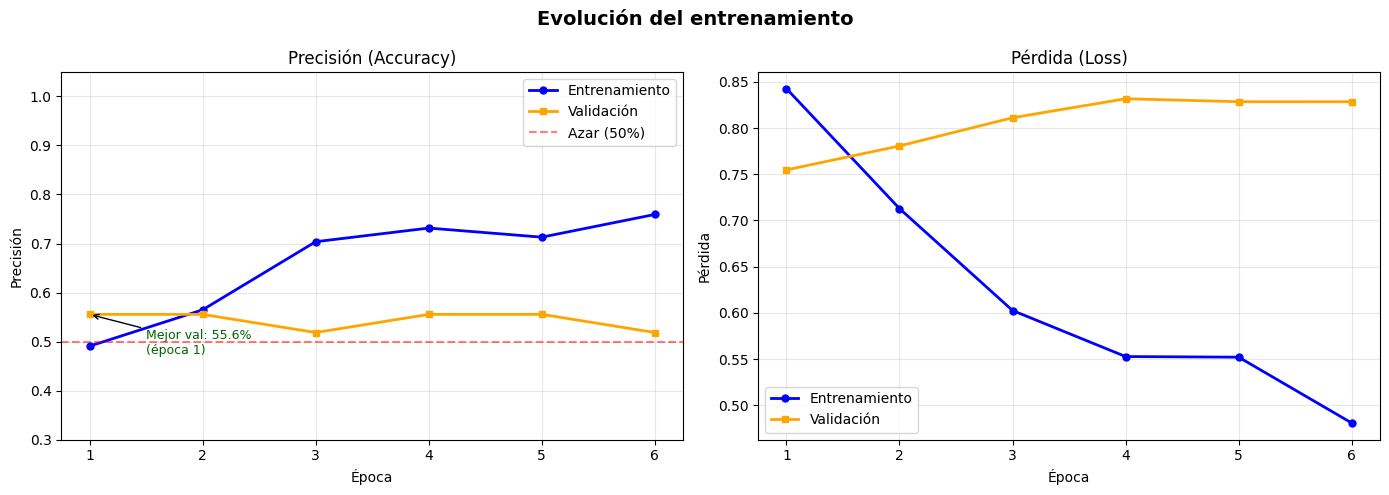

💾 Gráfico guardado como 'grafico_entrenamiento.png'

🔍 INTERPRETACIÓN AUTOMÁTICA DE LOS RESULTADOS:
   ⚠️  OVERFITTING detectado: la precisión de entrenamiento es mucho mayor
      que la de validación. El modelo memorizó los datos de entrenamiento
      en lugar de aprender patrones generales. Con solo 135 imágenes,
      esto era previsible. Necesitaríamos más datos para evitarlo.

   Precisión de entrenamiento final: 75.9%
   Precisión de validación final: 51.9%
   Diferencia (posible overfitting): 24.1%

✅ BLOQUE 3 COMPLETADO. Puedes ejecutar el Bloque 4.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOQUE 3 DE 5 · Entrenamiento del modelo                                   ║
# ║  Red Neuronal para predecir velocidad de adopción de animales                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
# QUÉ HACE ESTE BLOQUE:
#   1. Configura callbacks (herramientas auxiliares durante el entrenamiento)
#   2. Entrena el modelo durante un máximo de 20 épocas
#   3. Muestra el progreso en tiempo real
#   4. Dibuja gráficos de evolución de precisión y pérdida
#
# IMPORTANTE: ejecuta los Bloques 1 y 2 antes que este.
# Las variables X_train, X_val, y_train, y_val y 'modelo' deben existir.

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("🚀 Configurando el entrenamiento...")

# ── Paso 1: Configurar callbacks ─────────────────────────────────────────────
# Los callbacks son acciones automáticas que ocurren durante el entrenamiento.

# EarlyStopping: detiene el entrenamiento si la validación deja de mejorar.
# Así evitamos hacer épocas innecesarias que solo provocan overfitting.
#
# monitor='val_accuracy' → mira la precisión de validación (no la de entrenamiento)
# patience=5 → espera 5 épocas sin mejora antes de parar
# restore_best_weights=True → al parar, recupera los pesos de la mejor época
#   (no los del último momento, que pueden ser peores)
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1   # verbose=1 → muestra un mensaje cuando para
)

# ReduceLROnPlateau: si la pérdida de validación no mejora, reduce la velocidad
# de aprendizaje (learning rate). Esto ayuda al modelo a "afinar" más cuando
# está cerca de un buen resultado.
#
# factor=0.5 → reduce el learning rate a la mitad
# patience=3 → espera 3 épocas sin mejora antes de reducirlo
# min_lr=1e-7 → nunca baja de este valor mínimo
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

print("✅ Callbacks configurados:")
print("   - EarlyStopping: para si no mejora en 5 épocas")
print("   - ReduceLROnPlateau: reduce la velocidad de aprendizaje si se estanca")

# ── Paso 2: Entrenamiento ────────────────────────────────────────────────────
# model.fit() es la función que inicia el entrenamiento.
#
# X_train, y_train → las imágenes y etiquetas de entrenamiento
# epochs=20 → máximo 20 vueltas completas (EarlyStopping puede parar antes)
#
# batch_size=16:
#   En lugar de mostrar todas las imágenes de golpe, las agrupamos en lotes de 16.
#   Después de cada lote, el modelo ajusta sus pesos. Esto es más eficiente en
#   memoria y generalmente da mejores resultados que procesar todo de golpe.
#   Con 108 imágenes de entrenamiento, habrá ~7 lotes por época (108/16 ≈ 7).
#
# validation_data → después de cada época, evalúa con estas imágenes
#   (las de validación no se usan para aprender, solo para medir)
#
# callbacks → usamos los helpers que definimos arriba

print(f"\n🔁 Iniciando entrenamiento...")
print(f"   Imágenes de entrenamiento: {len(X_train)}")
print(f"   Imágenes de validación: {len(X_val)}")
print(f"   Épocas máximas: 20")
print(f"   Tamaño de lote (batch): 16")
print(f"\n{'─'*60}")

historial = modelo.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1   # Muestra el progreso en cada época
)

print(f"{'─'*60}")
print(f"\n🏁 Entrenamiento finalizado.")

# Mostramos un resumen de los resultados finales
epocas_reales = len(historial.history['accuracy'])
mejor_val_acc = max(historial.history['val_accuracy'])
print(f"   Épocas completadas: {epocas_reales}")
print(f"   Mejor precisión de validación: {mejor_val_acc:.1%}")
print(f"   Mejor precisión de entrenamiento: {max(historial.history['accuracy']):.1%}")

# ── Paso 3: Gráfico de precisión ─────────────────────────────────────────────
# Este gráfico es la forma más clara de ver si el modelo está aprendiendo
# correctamente o si hay overfitting (sobreajuste).
#
# Lo que queremos ver: las dos líneas suben juntas.
# Señal de overfitting: la azul (train) sigue subiendo pero la naranja (val) baja o se estanca.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evolución del entrenamiento', fontsize=14, fontweight='bold')

epocas = range(1, epocas_reales + 1)

# Gráfico 1: Precisión (Accuracy)
ax1.plot(epocas, historial.history['accuracy'],
         'b-o', label='Entrenamiento', linewidth=2, markersize=5)
ax1.plot(epocas, historial.history['val_accuracy'],
         'orange', linestyle='-', marker='s', label='Validación', linewidth=2, markersize=5)
ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Azar (50%)')
ax1.set_title('Precisión (Accuracy)', fontsize=12)
ax1.set_xlabel('Época')
ax1.set_ylabel('Precisión')
ax1.legend()
ax1.set_ylim([0.3, 1.05])
ax1.grid(True, alpha=0.3)

# Añadimos anotaciones para la mejor época de validación
mejor_epoca_val = historial.history['val_accuracy'].index(mejor_val_acc) + 1
ax1.annotate(f'Mejor val: {mejor_val_acc:.1%}\n(época {mejor_epoca_val})',
             xy=(mejor_epoca_val, mejor_val_acc),
             xytext=(mejor_epoca_val + 0.5, mejor_val_acc - 0.08),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=9, color='darkgreen')

# Gráfico 2: Pérdida (Loss)
# La pérdida mide cuánto se equivoca el modelo. Queremos que baje.
ax2.plot(epocas, historial.history['loss'],
         'b-o', label='Entrenamiento', linewidth=2, markersize=5)
ax2.plot(epocas, historial.history['val_loss'],
         'orange', linestyle='-', marker='s', label='Validación', linewidth=2, markersize=5)
ax2.set_title('Pérdida (Loss)', fontsize=12)
ax2.set_xlabel('Época')
ax2.set_ylabel('Pérdida')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('grafico_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Gráfico guardado como 'grafico_entrenamiento.png'")

# ── Interpretación automática ─────────────────────────────────────────────────
print("\n🔍 INTERPRETACIÓN AUTOMÁTICA DE LOS RESULTADOS:")

acc_final_train = historial.history['accuracy'][-1]
acc_final_val = historial.history['val_accuracy'][-1]
diferencia = acc_final_train - acc_final_val

if diferencia > 0.15:
    print("   ⚠️  OVERFITTING detectado: la precisión de entrenamiento es mucho mayor")
    print("      que la de validación. El modelo memorizó los datos de entrenamiento")
    print("      en lugar de aprender patrones generales. Con solo 135 imágenes,")
    print("      esto era previsible. Necesitaríamos más datos para evitarlo.")
elif mejor_val_acc > 0.60:
    print("   ✅ El modelo ha aprendido algo útil: supera claramente el azar (50%).")
    print("      Con más datos, los resultados mejorarían.")
else:
    print("   ℹ️  El modelo apenas supera el azar. Con 135 imágenes, las características")
    print("      visuales que predicen la adopción son difíciles de detectar.")
    print("      Esto es un resultado esperado dado el tamaño del dataset.")

print(f"\n   Precisión de entrenamiento final: {acc_final_train:.1%}")
print(f"   Precisión de validación final: {acc_final_val:.1%}")
print(f"   Diferencia (posible overfitting): {diferencia:.1%}")

print("\n✅ BLOQUE 3 COMPLETADO. Puedes ejecutar el Bloque 4.")


📊 Evaluando el modelo sobre el conjunto de validación...
   Total de imágenes evaluadas: 27
   Predicciones correctas: 15
   Precisión global: 55.6%


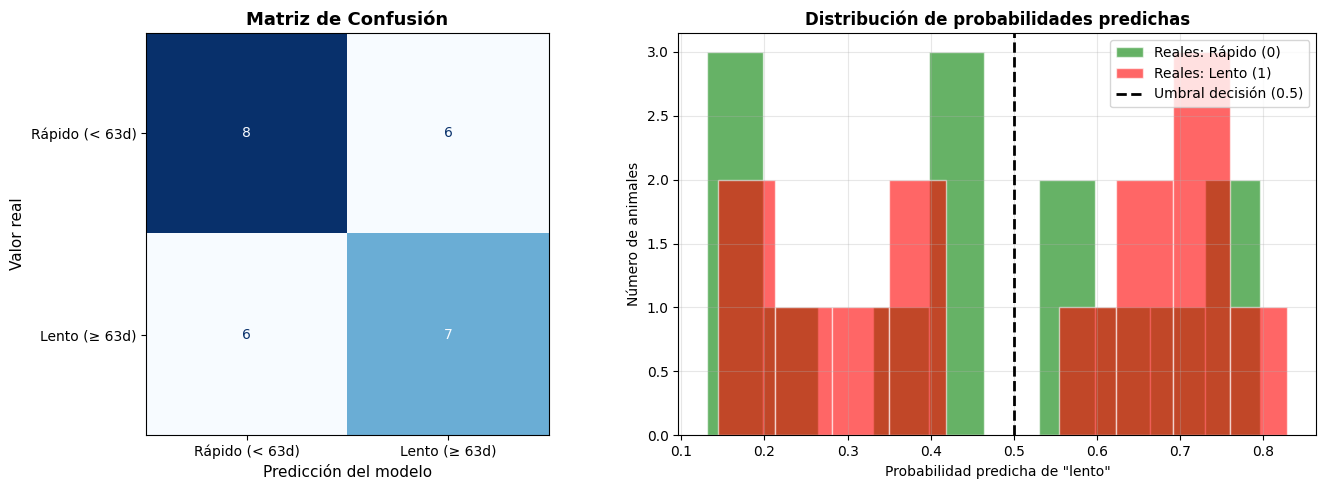

💾 Gráfico guardado como 'matriz_confusion.png'

🗺️  INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:
   ┌───────────────────────────────────────────────────┐
   │  Verdaderos Negativos (VN):  8                  │
   │  Predijo RÁPIDO y era RÁPIDO ✓                    │
   ├───────────────────────────────────────────────────┤
   │  Falsos Positivos (FP):  6                      │
   │  Predijo LENTO pero era RÁPIDO ✗                  │
   ├───────────────────────────────────────────────────┤
   │  Falsos Negativos (FN):  6                      │
   │  Predijo RÁPIDO pero era LENTO ✗                  │
   ├───────────────────────────────────────────────────┤
   │  Verdaderos Positivos (VP):  7                  │
   │  Predijo LENTO y era LENTO ✓                      │
   └───────────────────────────────────────────────────┘

📋 REPORTE DE CLASIFICACIÓN DETALLADO:
────────────────────────────────────────────────────────────
                precision    recall  f1-score   support

Rápido (< 63d)  

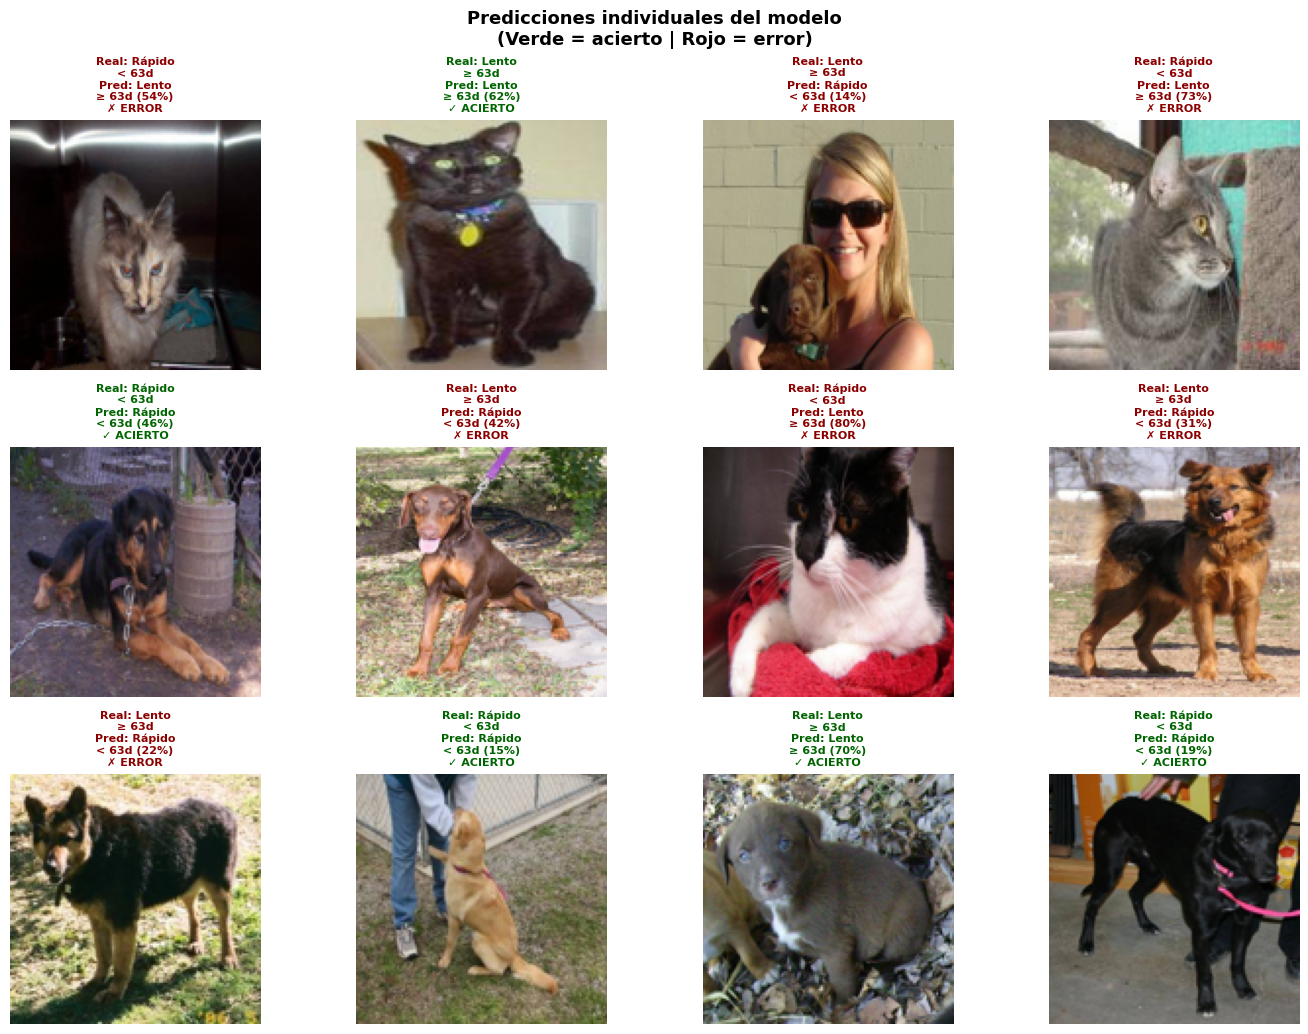

💾 Gráfico guardado como 'predicciones_individuales.png'

════════════════════════════════════════════════════════════
  RESUMEN FINAL DEL PROYECTO
════════════════════════════════════════════════════════════

  Dataset:
  • Animales usados (adoptados): 135
  • Entrenamiento: 108 | Validación: 27
  • Umbral de clasificación: 63 días de estancia

  Resultados:
  • Precisión de validación: 55.6%
  • Verdaderos Negativos (VN): 8 | Falsos Positivos (FP): 6
  • Falsos Negativos (FN): 6  | Verdaderos Positivos (VP): 7

  ¿Qué has aprendido?
  ✅ Preparar imágenes para deep learning (redimensionar, normalizar)
  ✅ Aplicar Transfer Learning con MobileNetV2
  ✅ Interpretar overfitting con gráficas de entrenamiento
  ✅ Leer una matriz de confusión y un reporte de clasificación
  ✅ Completar el ciclo completo de un proyecto de ML con imágenes

  Limitaciones con 135 imágenes:
  • Los resultados tienen alta variabilidad (dependen de qué imágenes
    caen en validación, algo aleatorio en cada ejecuci

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOQUE 4 DE 5 · Resultados y análisis final                                ║
# ║  Red Neuronal para predecir velocidad de adopción de animales                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
# QUÉ HACE ESTE BLOQUE:
#   1. Evalúa el modelo sobre el conjunto de validación
#   2. Muestra la matriz de confusión (tabla de aciertos y errores)
#   3. Muestra el reporte de clasificación con métricas detalladas
#   4. Visualiza predicciones individuales para imágenes concretas
#   5. Da una interpretación final de los resultados
#
# IMPORTANTE: ejecuta los Bloques 1, 2 y 3 antes que este.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

print("📊 Evaluando el modelo sobre el conjunto de validación...")

# ── Paso 1: Obtener predicciones ─────────────────────────────────────────────
# modelo.predict() procesa las imágenes y devuelve la probabilidad de clase 1
# para cada imagen. Un valor cercano a 1 = "lento", cercano a 0 = "rápido".

probabilidades = modelo.predict(X_val, verbose=0)
# probabilidades tiene shape (N, 1) → lo aplanamos a (N,) para facilitar el análisis
probabilidades = probabilidades.flatten()

# Convertimos probabilidades a predicciones binarias:
# Si probabilidad >= 0.5 → clase 1 (lento), si < 0.5 → clase 0 (rápido)
y_pred = (probabilidades >= 0.5).astype(int)

# Evaluamos precisión global
aciertos = (y_pred == y_val).sum()
total = len(y_val)
precision_global = aciertos / total

print(f"   Total de imágenes evaluadas: {total}")
print(f"   Predicciones correctas: {aciertos}")
print(f"   Precisión global: {precision_global:.1%}")

# ── Paso 2: Matriz de confusión ───────────────────────────────────────────────
# La matriz de confusión es una tabla 2×2 que muestra:
#   - Cuántos animales de clase 0 predijo bien como 0 (Verdaderos Negativos, VN)
#   - Cuántos animales de clase 0 predijo mal como 1 (Falsos Positivos, FP)
#   - Cuántos animales de clase 1 predijo mal como 0 (Falsos Negativos, FN)
#   - Cuántos animales de clase 1 predijo bien como 1 (Verdaderos Positivos, VP)

cm = confusion_matrix(y_val, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Matriz de confusión con colores
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Rápido (< 63d)', 'Lento (≥ 63d)']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicción del modelo', fontsize=11)
axes[0].set_ylabel('Valor real', fontsize=11)

# Añadimos etiquetas de interpretación manualmente
vn = cm[0, 0]  # Verdaderos Negativos
fp = cm[0, 1]  # Falsos Positivos
fn = cm[1, 0]  # Falsos Negativos
vp = cm[1, 1]  # Verdaderos Positivos

# Gráfico 2: Distribución de probabilidades predichas
axes[1].hist(probabilidades[y_val == 0], bins=10, alpha=0.6,
             color='green', label='Reales: Rápido (0)', edgecolor='white')
axes[1].hist(probabilidades[y_val == 1], bins=10, alpha=0.6,
             color='red', label='Reales: Lento (1)', edgecolor='white')
axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Umbral decisión (0.5)')
axes[1].set_title('Distribución de probabilidades predichas', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Probabilidad predicha de "lento"')
axes[1].set_ylabel('Número de animales')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Gráfico guardado como 'matriz_confusion.png'")

# Mostramos la interpretación de la matriz
print(f"\n🗺️  INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:")
print(f"   ┌───────────────────────────────────────────────────┐")
print(f"   │  Verdaderos Negativos (VN): {vn:2d}                  │")
print(f"   │  Predijo RÁPIDO y era RÁPIDO ✓                    │")
print(f"   ├───────────────────────────────────────────────────┤")
print(f"   │  Falsos Positivos (FP): {fp:2d}                      │")
print(f"   │  Predijo LENTO pero era RÁPIDO ✗                  │")
print(f"   ├───────────────────────────────────────────────────┤")
print(f"   │  Falsos Negativos (FN): {fn:2d}                      │")
print(f"   │  Predijo RÁPIDO pero era LENTO ✗                  │")
print(f"   ├───────────────────────────────────────────────────┤")
print(f"   │  Verdaderos Positivos (VP): {vp:2d}                  │")
print(f"   │  Predijo LENTO y era LENTO ✓                      │")
print(f"   └───────────────────────────────────────────────────┘")

# ── Paso 3: Reporte de clasificación ─────────────────────────────────────────
# El reporte muestra métricas más detalladas para cada clase:
#
# Precision: de todos los que predije como clase X, ¿cuántos eran realmente X?
#   → Evita "falsos positivos"
#
# Recall: de todos los que realmente eran clase X, ¿cuántos detecté correctamente?
#   → Evita "falsos negativos"
#
# F1-score: media harmónica de precision y recall. Equilibra ambas métricas.
#   Un F1 de 1.0 es perfecto; de 0.0 es el peor posible.
#   Si ambas clases tienen F1 similar al del azar (0.5), el modelo no aprendió.

print(f"\n📋 REPORTE DE CLASIFICACIÓN DETALLADO:")
print("─" * 60)
print(classification_report(
    y_val, y_pred,
    target_names=['Rápido (< 63d)', 'Lento (≥ 63d)'],
    digits=3
))
print("─" * 60)
print("   Precision: % de predicciones de cada clase que son correctas")
print("   Recall:    % de casos reales de cada clase que detecta el modelo")
print("   F1-score:  media equilibrada entre Precision y Recall (0=peor, 1=mejor)")
print("   Support:   número de imágenes reales de cada clase en validación")

# ── Paso 4: Visualización de predicciones individuales ───────────────────────
# Mostramos las primeras 12 imágenes del conjunto de validación con:
#   - La imagen del animal
#   - Su clase real (verde o roja)
#   - La predicción del modelo
#   - La probabilidad de la predicción

n_mostrar = min(12, len(X_val))
n_cols = 4
n_rows = (n_mostrar + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
fig.suptitle('Predicciones individuales del modelo\n(Verde = acierto | Rojo = error)',
             fontsize=13, fontweight='bold')

nombres_clase = {0: 'Rápido\n< 63d', 1: 'Lento\n≥ 63d'}

for i, ax in enumerate(axes.flat):
    if i < n_mostrar:
        ax.imshow(X_val[i])

        real = int(y_val[i])
        pred = int(y_pred[i])
        prob = probabilidades[i]
        acierto = (real == pred)

        # Color del borde: verde si acertó, rojo si se equivocó
        color_borde = 'green' if acierto else 'red'
        for spine in ax.spines.values():
            spine.set_edgecolor(color_borde)
            spine.set_linewidth(4)

        # Título con la información
        titulo = (f"Real: {nombres_clase[real]}\n"
                  f"Pred: {nombres_clase[pred]} ({prob:.0%})\n"
                  f"{'✓ ACIERTO' if acierto else '✗ ERROR'}")
        ax.set_title(titulo, fontsize=8,
                     color='darkgreen' if acierto else 'darkred',
                     fontweight='bold')
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.savefig('predicciones_individuales.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Gráfico guardado como 'predicciones_individuales.png'")

# ── Paso 5: Resumen final y reflexión ─────────────────────────────────────────
print("\n" + "═" * 60)
print("  RESUMEN FINAL DEL PROYECTO")
print("═" * 60)

print(f"\n  Dataset:")
print(f"  • Animales usados (adoptados): {len(X_val) + len(X_train)}")
print(f"  • Entrenamiento: {len(X_train)} | Validación: {len(X_val)}")
print(f"  • Umbral de clasificación: 63 días de estancia")

print(f"\n  Resultados:")
print(f"  • Precisión de validación: {precision_global:.1%}")
print(f"  • Verdaderos Negativos (VN): {vn} | Falsos Positivos (FP): {fp}")
print(f"  • Falsos Negativos (FN): {fn}  | Verdaderos Positivos (VP): {vp}")

print(f"\n  ¿Qué has aprendido?")
print(f"  ✅ Preparar imágenes para deep learning (redimensionar, normalizar)")
print(f"  ✅ Aplicar Transfer Learning con MobileNetV2")
print(f"  ✅ Interpretar overfitting con gráficas de entrenamiento")
print(f"  ✅ Leer una matriz de confusión y un reporte de clasificación")
print(f"  ✅ Completar el ciclo completo de un proyecto de ML con imágenes")

print(f"\n  Limitaciones con 135 imágenes:")
print(f"  • Los resultados tienen alta variabilidad (dependen de qué imágenes")
print(f"    caen en validación, algo aleatorio en cada ejecución).")
print(f"  • Para resultados fiables necesitaríamos 500+ imágenes por clase.")
print(f"  • Aun así, hemos seguido exactamente el mismo proceso que usan")
print(f"    los investigadores con datasets más grandes.")
print(f"\n" + "═" * 60)


🔍 Iniciando análisis Grad-CAM...
   (¿en qué zonas de las fotos se fija la red para predecir la adopción?)
   ✅ Submodelo MobileNetV2 encontrado: 'mobilenetv2_1.00_128'
   ✅ Capa convolucional encontrada: 'Conv_1'
   Forma de salida de la capa: (None, 4, 4, 1280)

✅ Submodelo Grad-CAM de la base construido correctamente

📝 Función Grad-CAM adaptada y definida correctamente

🖼️  Calculando mapas de calor para 8 imágenes...
   [1/8] Imagen 1: real=Lento, pred=Lento (62%)
   [2/8] Imagen 4: real=Rápido, pred=Rápido (46%)
   [3/8] Imagen 9: real=Rápido, pred=Rápido (15%)
   [4/8] Imagen 10: real=Lento, pred=Lento (70%)
   [5/8] Imagen 0: real=Rápido, pred=Lento (54%)
   [6/8] Imagen 2: real=Lento, pred=Rápido (14%)
   [7/8] Imagen 3: real=Rápido, pred=Lento (73%)
   [8/8] Imagen 5: real=Lento, pred=Rápido (42%)

✅ Mapas de calor calculados


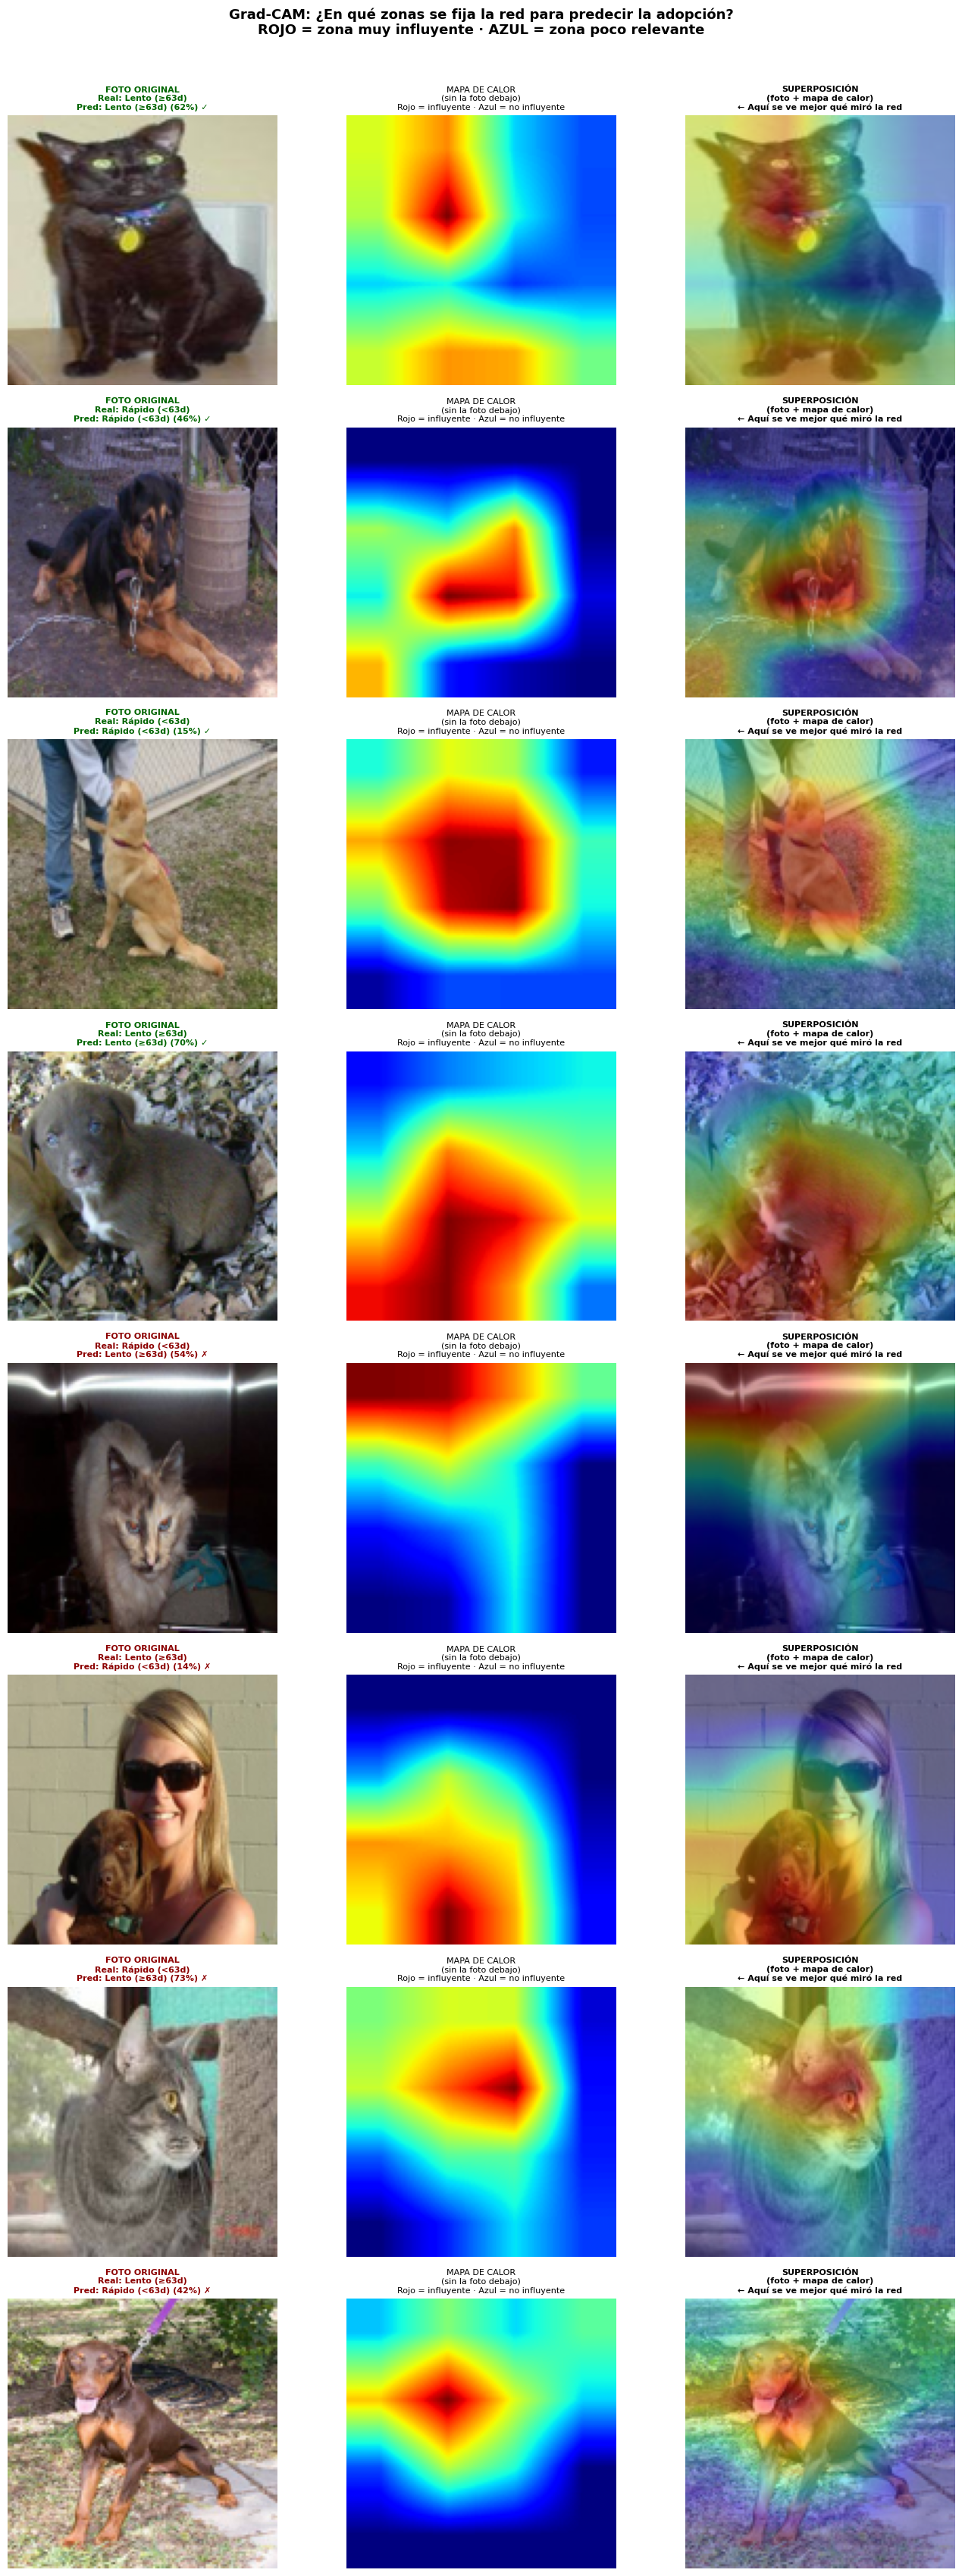

💾 Gráfico guardado como 'gradcam_adopcion.png'

📊 Calculando mapas de calor medios por clase predicha...


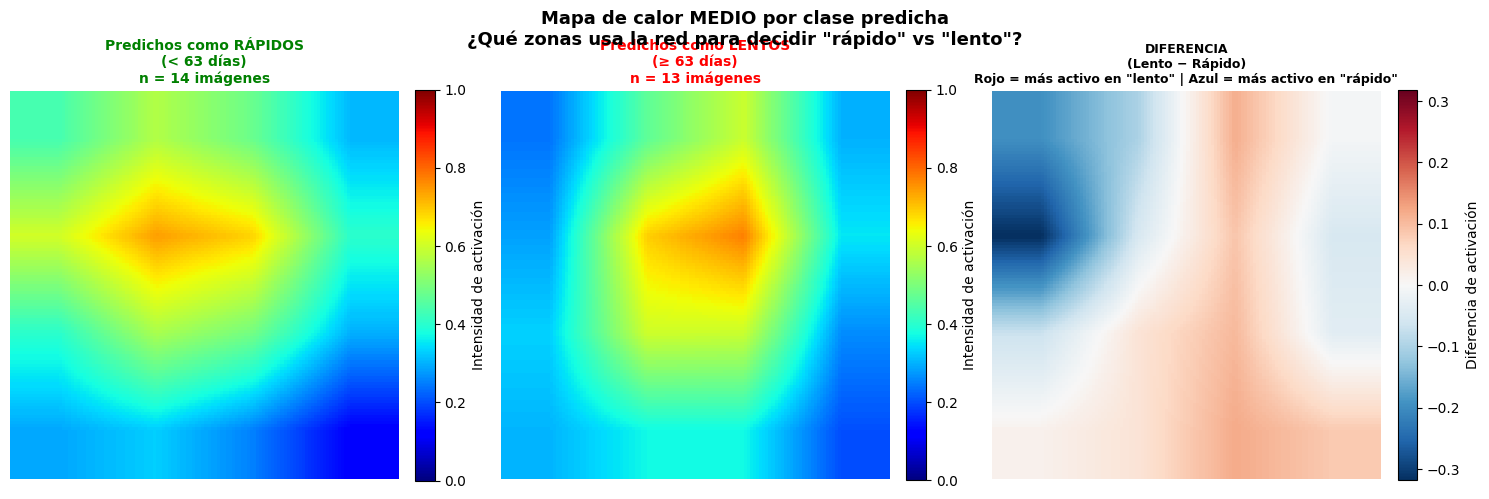

💾 Gráfico comparativo guardado como 'gradcam_comparativa.png'

✅ BLOQUE 5 COMPLETADO CON ÉXITO.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOQUE 5 DE 5 · Grad-CAM: ¿en qué se fija la red para predecir?           ║
# ║  Red Neuronal para predecir velocidad de adopción de animales                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
# QUÉ HACE ESTE BLOQUE:
#   1. Explica qué es Grad-CAM con una analogía sencilla
#   2. Construye el "submodelo" de la base necesario para extraer mapas de activación
#   3. Genera mapas de calor para imágenes de validación reconstruyendo el flujo en la cinta
#   4. Muestra los mapas superpuestos sobre las fotos originales
#   5. Da una interpretación visual de qué zonas influyeron en la predicción

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow.keras import Model

print("🔍 Iniciando análisis Grad-CAM...")
print("   (¿en qué zonas de las fotos se fija la red para predecir la adopción?)")

# ── Paso 1: Encontrar la última capa convolucional de MobileNetV2 ─────────────
CAPA_GRADCAM = 'Conv_1'  # Nombre de la última capa convolucional de MobileNetV2

base_mobilenet = None
for capa in modelo.layers:
    if isinstance(capa, tf.keras.Model):
        base_mobilenet = capa
        print(f"   ✅ Submodelo MobileNetV2 encontrado: '{capa.name}'")
        break

if base_mobilenet is None:
    raise RuntimeError(
        "No se encontró el submodelo MobileNetV2 dentro de 'modelo'. "
        "Asegúrate de haber ejecutado los Bloques 1, 2 y 3 antes que este."
    )

nombres_base = [c.name for c in base_mobilenet.layers]
if CAPA_GRADCAM in nombres_base:
    capa_objetivo = base_mobilenet.get_layer(CAPA_GRADCAM)
    print(f"   ✅ Capa convolucional encontrada: '{CAPA_GRADCAM}'")
else:
    capa_objetivo = None
    for c in reversed(base_mobilenet.layers):
        try:
            sal = c.output
            if len(sal.shape) == 4:
                capa_objetivo = c
                CAPA_GRADCAM = c.name
                break
        except Exception:
            continue
    if capa_objetivo is None:
        raise RuntimeError("No se encontró ninguna capa convolucional en MobileNetV2.")
    print(f"   Usando capa alternativa: '{CAPA_GRADCAM}'")

forma_salida = tuple(capa_objetivo.output.shape)
print(f"   Forma de salida de la capa: {forma_salida}")

# ── Paso 2: Crear el modelo Grad-CAM de la base ──────────────────────────────
# Para evitar errores de grafos desconectados en Keras moderno, creamos un submodelo
# que opera estrictamente dentro de MobileNetV2. Este nos devolverá:
#   1. Las activaciones de la capa convolucional objetivo (el "dónde")
#   2. La salida final de MobileNetV2 (para poder seguir con el resto del modelo)
base_gradcam_model = Model(
    inputs=base_mobilenet.inputs,
    outputs=[capa_objetivo.output, base_mobilenet.output]
)

print(f"\n✅ Submodelo Grad-CAM de la base construido correctamente")

# ── Paso 3: Función para calcular el mapa de calor ───────────────────────────
def calcular_gradcam(imagen, clase_objetivo=None):
    """
    Calcula el mapa de calor Grad-CAM para una imagen recreando el flujo del grafo.
    """
    img_lote = np.expand_dims(imagen, axis=0)
    img_tensor = tf.cast(img_lote, tf.float32)

    # Usamos GradientTape para rastrear los gradientes durante la ejecución manual
    with tf.GradientTape() as tape:
        # 1. Replicamos exactamente el preprocesamiento del Bloque 2
        x = img_tensor * 255.0
        x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

        # 2. Obtenemos las activaciones intermedias y la salida de la base
        activaciones, base_outputs = base_gradcam_model(x, training=False)

        # Obligamos a la cinta a observar las activaciones para calcular derivadas respecto a ellas
        tape.watch(activaciones)

        # 3. Pasamos los mapas finales de la base por las capas del modelo principal
        x = modelo.get_layer('pooling_global')(base_outputs)
        x = modelo.get_layer('dropout_regularizacion')(x, training=False)
        prediccion = modelo.get_layer('prediccion')(x)

        # Decidimos qué clase analizar
        if clase_objetivo is None:
            clase_objetivo = int(prediccion[0, 0] >= 0.5)

        # Extraemos la puntuación de la clase seleccionada
        if clase_objetivo == 1:
            puntuacion_clase = prediccion[0, 0]   # Probabilidad de "lento"
        else:
            puntuacion_clase = 1 - prediccion[0, 0]  # Probabilidad de "rápido"

    # Calculamos los gradientes de la predicción respecto a las activaciones de Conv_1
    gradientes = tape.gradient(puntuacion_clase, activaciones)

    # Promedio de los gradientes para medir la importancia de cada canal
    importancia_canales = tf.reduce_mean(gradientes, axis=(0, 1, 2))

    # Ponderamos los mapas de activación
    activaciones_np = activaciones[0].numpy()
    mapa_ponderado = np.zeros(activaciones_np.shape[:2], dtype=np.float32)

    for i, peso in enumerate(importancia_canales.numpy()):
        mapa_ponderado += peso * activaciones_np[:, :, i]

    # ReLU: Conservamos solo lo que influye positivamente en la decisión
    mapa_ponderado = np.maximum(mapa_ponderado, 0)

    # Escalamos el mapa pequeño de vuelta a 128x128
    mapa_resized = tf.image.resize(
        mapa_ponderado[:, :, np.newaxis],
        [128, 128]
    ).numpy()[:, :, 0]

    # Normalizamos
    if mapa_resized.max() > 0:
        mapa_normalizado = mapa_resized / mapa_resized.max()
    else:
        mapa_normalizado = mapa_resized

    return mapa_normalizado, float(prediccion[0, 0])


print("\n📝 Función Grad-CAM adaptada y definida correctamente")

# ── Paso 4: Generar mapas de calor para imágenes seleccionadas ───────────────
probs_gradcam = modelo.predict(X_val, verbose=0).flatten()
y_pred_gradcam = (probs_gradcam >= 0.5).astype(int)

indices_aciertos  = np.where(y_pred_gradcam == y_val)[0]
indices_errores   = np.where(y_pred_gradcam != y_val)[0]

n_aciertos = min(4, len(indices_aciertos))
n_errores  = min(4, len(indices_errores))

indices_seleccionados = np.concatenate([
    indices_aciertos[:n_aciertos],
    indices_errores[:n_errores]
])

if len(indices_seleccionados) < 8:
    todos = np.arange(len(X_val))
    faltantes = [i for i in todos if i not in indices_seleccionados]
    indices_seleccionados = np.concatenate([indices_seleccionados, faltantes[:8 - len(indices_seleccionados)]])

indices_seleccionados = indices_seleccionados[:8]

print(f"\n🖼️  Calculando mapas de calor para {len(indices_seleccionados)} imágenes...")

mapas_calor = []
predicciones_vals = []

for i, idx in enumerate(indices_seleccionados):
    mapa, pred = calcular_gradcam(X_val[idx])
    mapas_calor.append(mapa)
    predicciones_vals.append(pred)
    print(f"   [{i+1}/{len(indices_seleccionados)}] Imagen {idx}: "
          f"real={'Rápido' if y_val[idx]==0 else 'Lento'}, "
          f"pred={'Rápido' if pred < 0.5 else 'Lento'} ({pred:.0%})")

print("\n✅ Mapas de calor calculados")

# ── Paso 5: Visualización principal ──────────────────────────────────────────
n_imgs  = len(indices_seleccionados)
n_cols  = 3
fig, axes = plt.subplots(n_imgs, n_cols, figsize=(14, 4.2 * n_imgs))
fig.suptitle(
    'Grad-CAM: ¿En qué zonas se fija la red para predecir la adopción?\n'
    'ROJO = zona muy influyente · AZUL = zona poco relevante',
    fontsize=13, fontweight='bold', y=1.01
)

# Corrección para compatibilidad con matplotlib moderno
colormap = plt.get_cmap('jet')

for fila, (idx, mapa, pred) in enumerate(zip(indices_seleccionados, mapas_calor, predicciones_vals)):
    imagen_original = X_val[idx]
    real   = int(y_val[idx])
    pred_clase = int(pred >= 0.5)
    acierto    = (real == pred_clase)

    nombre_real  = "Rápido (<63d)" if real == 0 else "Lento (≥63d)"
    nombre_pred  = "Rápido (<63d)" if pred_clase == 0 else "Lento (≥63d)"
    color_titulo = 'darkgreen' if acierto else 'darkred'
    simbolo      = '✓' if acierto else '✗'

    # Panel izquierdo: original
    ax_orig = axes[fila, 0] if n_imgs > 1 else axes[0]
    ax_orig.imshow(imagen_original)
    ax_orig.set_title(f'FOTO ORIGINAL\nReal: {nombre_real}\nPred: {nombre_pred} ({pred:.0%}) {simbolo}', fontsize=8, fontweight='bold', color=color_titulo)
    ax_orig.axis('off')

    # Panel central: mapa solo
    ax_mapa = axes[fila, 1] if n_imgs > 1 else axes[1]
    ax_mapa.imshow(mapa, cmap='jet', vmin=0, vmax=1)
    ax_mapa.set_title('MAPA DE CALOR\n(sin la foto debajo)\nRojo = influyente · Azul = no influyente', fontsize=8)
    ax_mapa.axis('off')

    # Panel derecho: superposición
    mapa_rgba    = colormap(mapa)
    mapa_rgb     = mapa_rgba[:, :, :3]
    superposicion = 0.6 * imagen_original + 0.4 * mapa_rgb
    superposicion = np.clip(superposicion, 0, 1)

    ax_super = axes[fila, 2] if n_imgs > 1 else axes[2]
    ax_super.imshow(superposicion)
    ax_super.set_title('SUPERPOSICIÓN\n(foto + mapa de calor)\n← Aquí se ve mejor qué miró la red', fontsize=8, fontweight='bold')
    ax_super.axis('off')

plt.tight_layout()
plt.savefig('gradcam_adopcion.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Gráfico guardado como 'gradcam_adopcion.png'")

# ── Paso 6: Análisis comparativo rápido vs lento ─────────────────────────────
print(f"\n📊 Calculando mapas de calor medios por clase predicha...")
mapas_rapidos = []
mapas_lentos  = []

for idx in range(len(X_val)):
    mapa, pred = calcular_gradcam(X_val[idx])
    if pred < 0.5:
        mapas_rapidos.append(mapa)
    else:
        mapas_lentos.append(mapa)

if mapas_rapidos and mapas_lentos:
    mapa_medio_rapido = np.mean(mapas_rapidos, axis=0)
    mapa_medio_lento  = np.mean(mapas_lentos, axis=0)

    fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
    fig2.suptitle('Mapa de calor MEDIO por clase predicha\n¿Qué zonas usa la red para decidir "rápido" vs "lento"?', fontsize=13, fontweight='bold')

    im1 = axes2[0].imshow(mapa_medio_rapido, cmap='jet', vmin=0, vmax=1)
    axes2[0].set_title(f'Predichos como RÁPIDOS\n(< 63 días)\nn = {len(mapas_rapidos)} imágenes', fontsize=10, color='green', fontweight='bold')
    axes2[0].axis('off')
    plt.colorbar(im1, ax=axes2[0], fraction=0.046, pad=0.04, label='Intensidad de activación')

    im2 = axes2[1].imshow(mapa_medio_lento, cmap='jet', vmin=0, vmax=1)
    axes2[1].set_title(f'Predichos como LENTOS\n(≥ 63 días)\nn = {len(mapas_lentos)} imágenes', fontsize=10, color='red', fontweight='bold')
    axes2[1].axis('off')
    plt.colorbar(im2, ax=axes2[1], fraction=0.046, pad=0.04, label='Intensidad de activación')

    diferencia = mapa_medio_lento - mapa_medio_rapido
    vmax_dif   = max(abs(diferencia.min()), abs(diferencia.max())) + 1e-6
    im3 = axes2[2].imshow(diferencia, cmap='RdBu_r', vmin=-vmax_dif, vmax=vmax_dif)
    axes2[2].set_title('DIFERENCIA\n(Lento − Rápido)\nRojo = más activo en "lento" | Azul = más activo en "rápido"', fontsize=9, fontweight='bold')
    axes2[2].axis('off')
    plt.colorbar(im3, ax=axes2[2], fraction=0.046, pad=0.04, label='Diferencia de activación')

    plt.tight_layout()
    plt.savefig('gradcam_comparativa.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("💾 Gráfico comparativo guardado como 'gradcam_comparativa.png'")

print("\n✅ BLOQUE 5 COMPLETADO CON ÉXITO.")